In [6]:
# ensure classes imported from .py files are dynamically updated
%load_ext autoreload
%autoreload 2

# plot matplots nicely
%matplotlib inline  

In [3]:
from stericheight.utils import *
from stericheight.data_handler import *
from stericheight.plotting_fns import *
from stericheight.steric_height import *

pf = PlottingFns()

In [14]:
import cartopy.crs as ccrs
import xarray as xr
import cmocean
import matplotlib.patches as mpatches

In [4]:
dot_ds = DOT().ds
lwe_ds = GRACE().ds
msl_ds = ERA5().ds

sha = StericHeight(ssh_ref='DOT',
                   ssh=dot_ds.dot,
                   lwe=lwe_ds.lwe_thickness,
                   msl=msl_ds.msl
                  ).get_sha()


gpha = GPHA()

In [41]:
# test. get a timeseries of steric height and corresponding sst from argo data at Dalton Polynya
# define study area
extent = [116,123,-67.5,-65]
lon_bounds = extent[:2]
lat_bounds = extent[2:]

In [12]:
elevation = GEBCO().ds.elevation

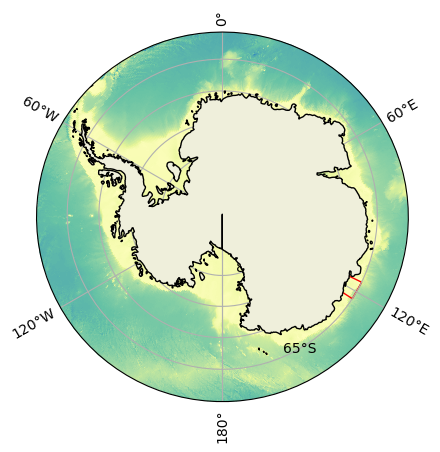

In [20]:
fig, ax = plt.subplots(subplot_kw={"projection":ccrs.SouthPolarStereo()})
pf.sp(ax,elevation,sea='Small Southern Ocean')
ax.add_patch(mpatches.Rectangle(xy=[extent[0], extent[2]],
                                width=extent[1]-extent[0],
                                height=extent[3]-extent[2],
                                facecolor='none', edgecolor='r',
                                transform=ccrs.PlateCarree()))

In [45]:
lon_bounds

[116, 123]

In [46]:
sha_studyregion = sha.sel(latitude=slice(lat_bounds[0],lat_bounds[1])).sel(longitude=slice(lon_bounds[0],lon_bounds[1]))

In [57]:
# show average seasonal anomaly in the area
sha_cmt = sha_studyregion.sha.groupby('time.month').mean()
sha_winter = sha_cmt.sel(month=[7,8,9]).mean('month')
sha_spring = sha_cmt.sel(month=[10,11,12]).mean('month')
sha_summer = sha_cmt.sel(month=[1,2,3]).mean('month')
sha_autumn = sha_cmt.sel(month=[4,5,6]).mean('month')



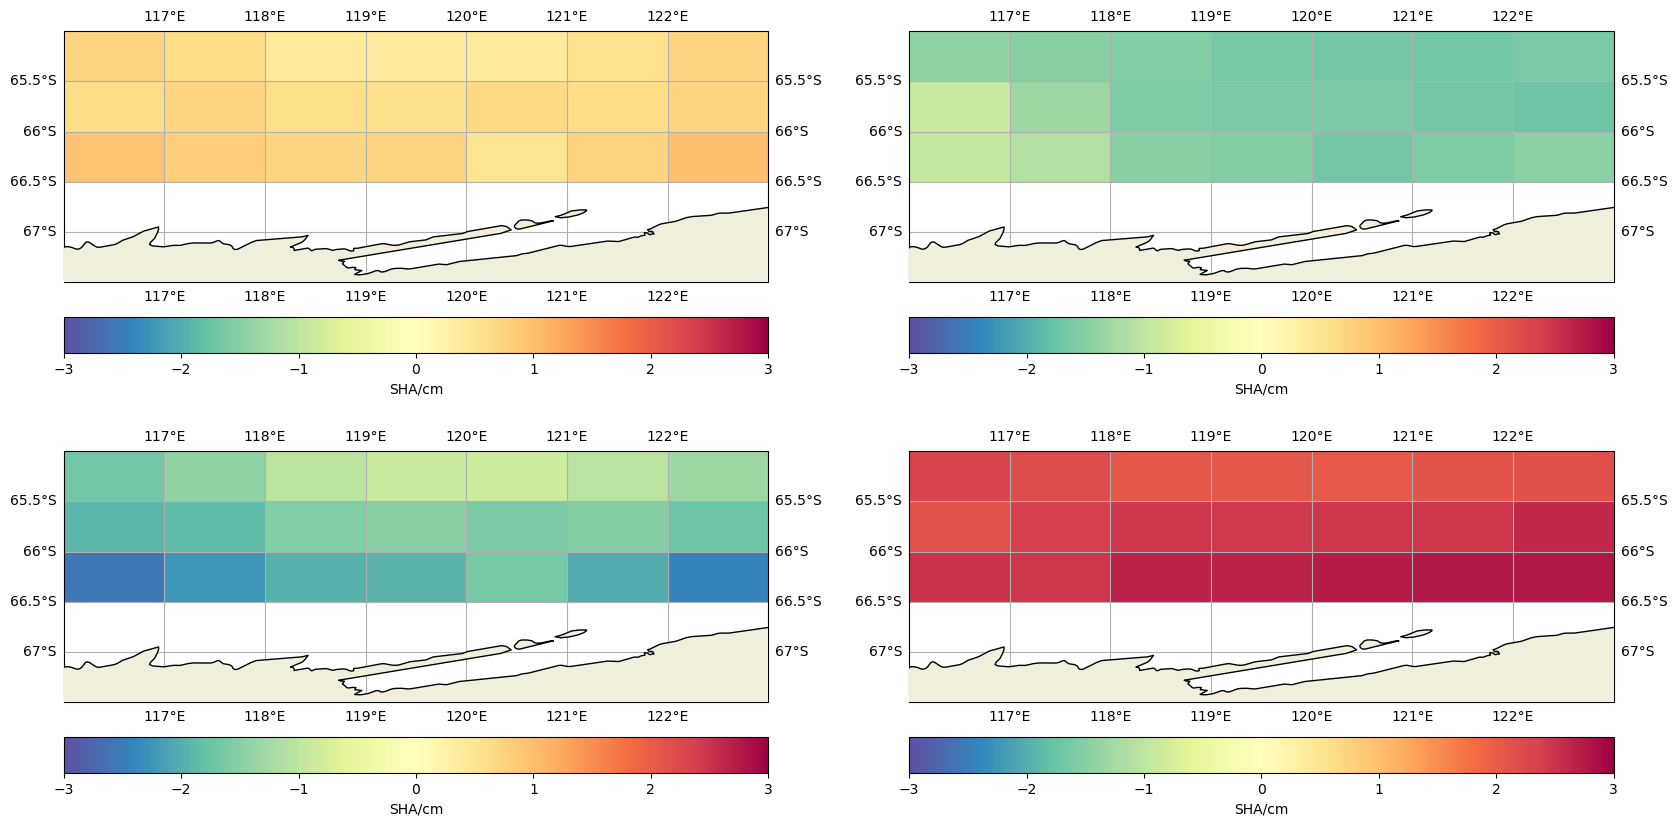

In [59]:
fig, ax = plt.subplots(2,2,figsize=(20,10), subplot_kw={"projection":ccrs.PlateCarree()})
pf.sp(ax[0][0],sha_winter,extent=extent,cbar="SHA/cm",vmin=-3,vmax=3)
pf.sp(ax[0][1],sha_spring,extent=extent,cbar="SHA/cm",vmin=-3,vmax=3)
pf.sp(ax[1][0],sha_summer,extent=extent,cbar="SHA/cm",vmin=-3,vmax=3)
pf.sp(ax[1][1],sha_autumn,extent=extent,cbar="SHA/cm",vmin=-3,vmax=3)

